In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
print(os.listdir('/kaggle/input/competitions/optiver-realized-volatility-prediction'))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

['trade_train.parquet', 'sample_submission.csv', 'book_test.parquet', 'trade_test.parquet', 'book_train.parquet', 'train.csv', 'test.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

plt.style.use('bmh')
pd.set_option('display.max_columns', None)

def calc_wap1(df):
    wap = (df['bid_price1'] * df['ask_size1'] + df['ask_price1']*df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])
    return wap

def calc_wap2(df):
    wap = (df['bid_price2'] * df['ask_size2'] + df['ask_price2']*df['bid_size2']) / (df['bid_size2'] + df['ask_size2'])
    return wap

def log_return(series):
    return np.log(series).diff().fillna(0)

def realized_volatility(series_log_return):
    return np.sqrt(np.sum(series_log_return ** 2))

In [3]:
DATA_DIR = '../input/competitions/optiver-realized-volatility-prediction/'
BOOK_TRAIN_PATH = os.path.join(DATA_DIR, 'book_train.parquet/stock_id=0')

df_book = pd.read_parquet(BOOK_TRAIN_PATH)
df_book['stock_id'] = 0
df_book.shape
df_book.head()

,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2,stock_id
0,5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100,0
1,5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100,0
2,5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100,0
3,5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0
4,5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0


In [4]:
sample_time_id = df_book['time_id'].unique()[0]
df_sample = df_book[df_book['time_id']==sample_time_id].copy()
df_sample

,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2,stock_id
0,5,0,1.001422,1.002301,1.001370,1.002353,3,226,2,100,0
1,5,1,1.001422,1.002301,1.001370,1.002353,3,100,2,100,0
2,5,5,1.001422,1.002301,1.001370,1.002405,3,100,2,100,0
3,5,6,1.001422,1.002301,1.001370,1.002405,3,126,2,100,0
4,5,7,1.001422,1.002301,1.001370,1.002405,3,126,2,100,0
...,...,...,...,...,...,...,...,...,...,...,...
297,5,585,1.003129,1.003749,1.003025,1.003801,100,3,26,3,0
298,5,586,1.003129,1.003749,1.002612,1.003801,100,3,2,3,0
299,5,587,1.003129,1.003749,1.003025,1.003801,100,3,26,3,0
300,5,588,1.003129,1.003749,1.002612,1.003801,100,3,2,3,0


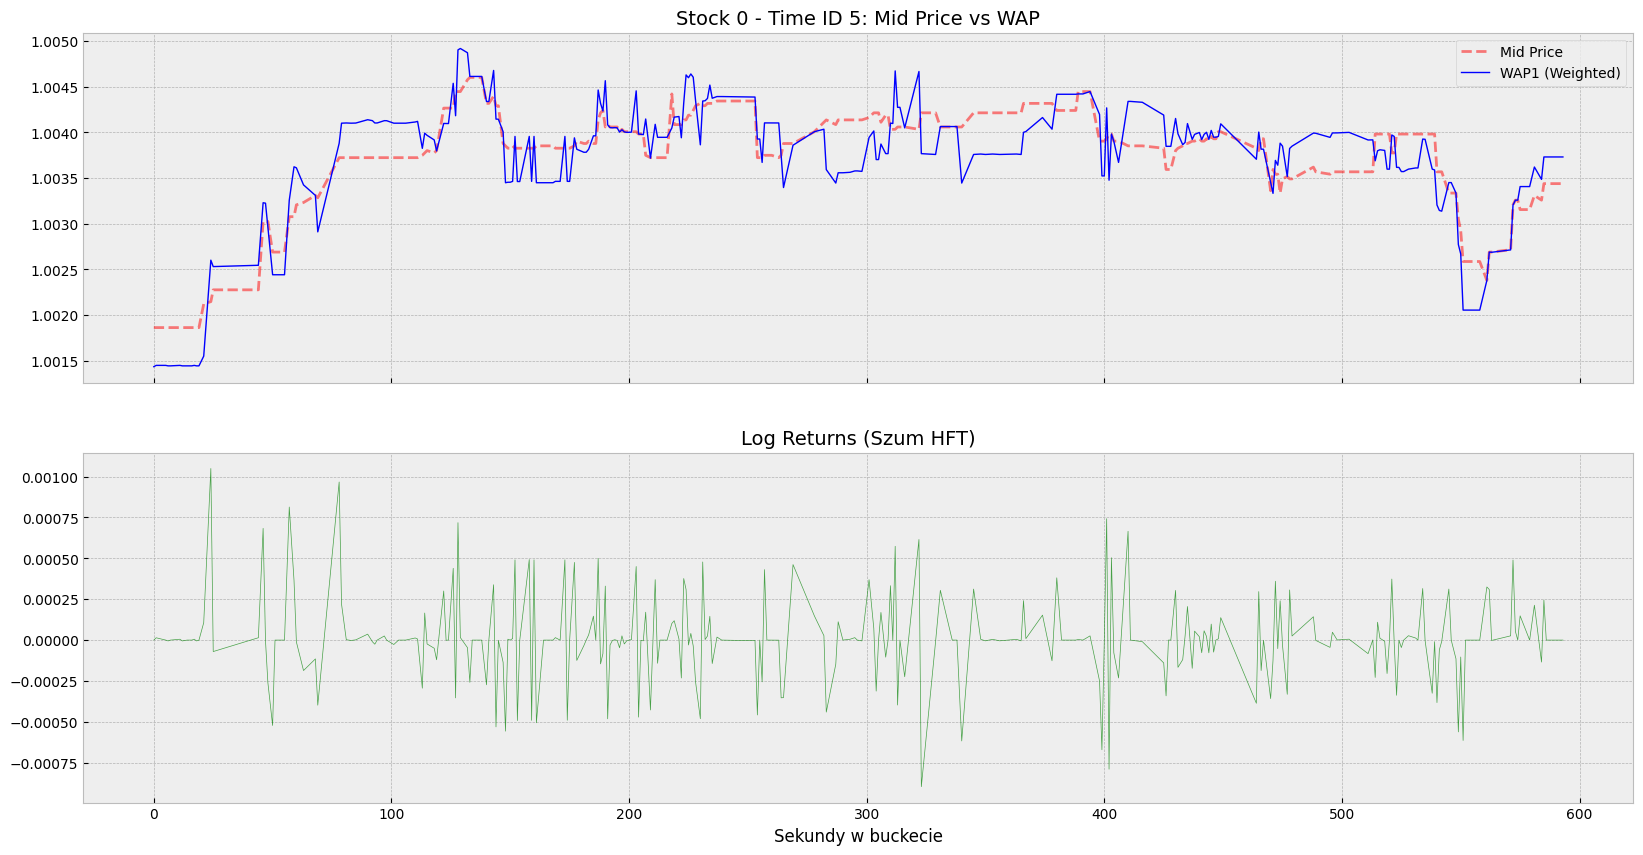

0.004499364172786559


In [5]:


df_sample['wap1'] = calc_wap1(df_sample)
df_sample['mid_price'] = (df_sample['bid_price1'] + df_sample['ask_price1']) / 2
df_sample['log_return'] = log_return(df_sample['wap1'])

fig, ax = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

ax[0].plot(df_sample['seconds_in_bucket'], df_sample['mid_price'], label='Mid Price', color='red', alpha=0.5, linestyle='--')
ax[0].plot(df_sample['seconds_in_bucket'], df_sample['wap1'], label='WAP1 (Weighted)', color='blue', linewidth=1)
ax[0].set_title(f'Stock 0 - Time ID {sample_time_id}: Mid Price vs WAP', fontsize=14)
ax[0].legend()

ax[1].plot(df_sample['seconds_in_bucket'], df_sample['log_return'], color='green', alpha=0.7, linewidth=0.5)
ax[1].set_title('Log Returns (Szum HFT)', fontsize=14)
ax[1].set_xlabel('Sekundy w buckecie')

plt.show()

vol = realized_volatility(df_sample['log_return'])
print(vol)

In [6]:
def get_stock_stat(stock_id, data_dir):
    file_path = f'{data_dir}book_train.parquet/stock_id={stock_id}'
    df_book = pd.read_parquet(file_path)
    df_book['wap1'] = calc_wap1(df_book)
    df_book['log_return']=df_book.groupby('time_id')['wap1'].transform(log_return)
    df_vol = df_book.groupby('time_id')['log_return'].agg(realized_volatility).reset_index()
    df_vol['stock_id'] = stock_id
    return df_vol

In [7]:
stock_ids = [int(i.split('=')[-1]) for i in glob.glob(DATA_DIR+'book_train.parquet/stock_id=*')]
len(stock_ids)

112

In [8]:
from joblib import Parallel, delayed
df_list = Parallel(n_jobs=-1, verbose=1)(
    delayed(get_stock_stat)(stock_id, DATA_DIR) for stock_id in stock_ids
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   39.7s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:  1.6min finished


In [9]:
df_train_features = pd.concat(df_list, ignore_index=True)
df_train_features

,time_id,log_return,stock_id
0,5,0.007263,97
1,11,0.002919,97
2,16,0.003799,97
3,31,0.003753,97
4,62,0.004365,97
...,...,...,...
428927,32751,0.005173,6
428928,32753,0.002747,6
428929,32758,0.004213,6
428930,32763,0.006068,6


In [10]:
df_train_features['row_id'] = df_train_features['stock_id'].astype(str) + '-' + df_train_features['time_id'].astype(str)
df_train_features.head()

,time_id,log_return,stock_id,row_id
0,5,0.007263,97,97-5
1,11,0.002919,97,97-11
2,16,0.003799,97,97-16
3,31,0.003753,97,97-31
4,62,0.004365,97,97-62


In [11]:
train_csv = pd.read_csv(DATA_DIR + 'train.csv')
train_csv['row_id'] = train_csv['stock_id'].astype(str) + '-' + train_csv['time_id'].astype(str)
train_csv = train_csv[['row_id', 'target']]

df_joined = df_train_features.merge(train_csv, on='row_id', how='left')

In [12]:
corr = df_joined['log_return'].corr(df_joined['target'])
corr

np.float64(0.8737773835083135)

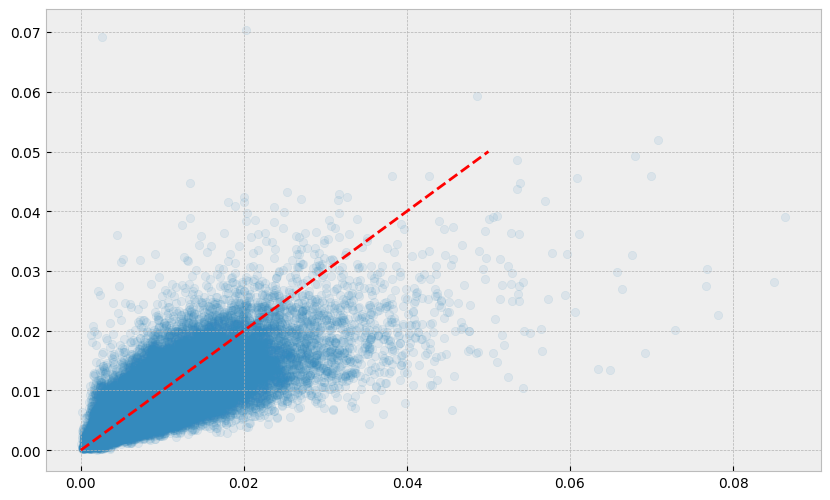

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df_joined['log_return'], df_joined['target'], alpha=0.1)
plt.plot([0, 0.05], [0, 0.05], color='red', linestyle='--')
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true-y_pred) / y_true)))

df_joined = df_joined.rename(columns={'log_return': 'vol_past'})

train_data = df_joined.dropna()

X = train_data[['vol_past']]
y = train_data['target']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(rmspe(y, y_pred))
print(r2_score(y, y_pred))
print(model.coef_[0])
print(model.intercept_)

0.3543495700912601
0.7634869159306337
0.7154384894880976
0.0008518524551161771


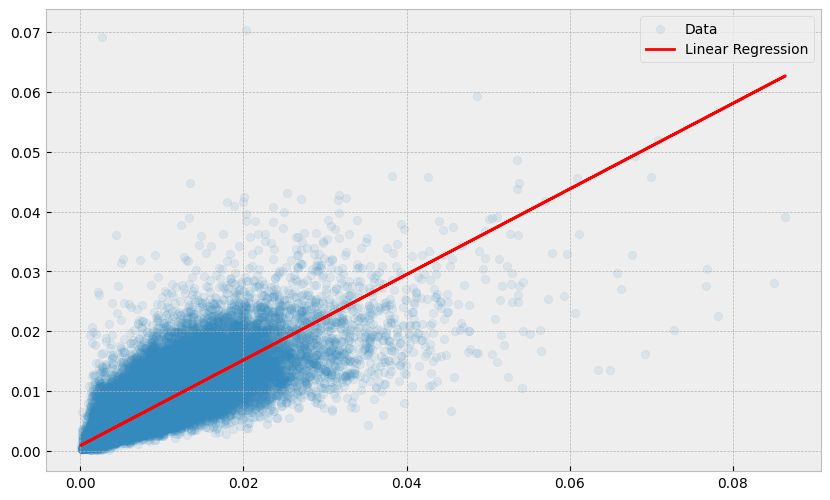

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(train_data['vol_past'], train_data['target'], alpha=0.1, label='Data')
plt.plot(train_data['vol_past'], y_pred, color='red', linewidth=2, label='Linear Regression')
plt.legend()
plt.show()

In [16]:
def get_trade_stat(stock_id, data_dir):
    file_path = f'{data_dir}trade_train.parquet/stock_id={stock_id}'
    try:
        df_trade = pd.read_parquet(file_path)
    except:
        return pd.DataFrame()

    df_trade['log_return'] = df_trade.groupby('time_id')['price'].transform(log_return)

    aggregate_dict = {
        'log_return': [realized_volatility],
        'seconds_in_bucket': ['count'],
        'size': ['sum', 'mean'],
        'order_count': ['mean']
    }

    df_trade_agg = df_trade.groupby('time_id').agg(aggregate_dict)
    df_trade_agg.columns = ['trade_' + '_'.join(col).strip() for col in df_trade_agg.columns.values]
    df_trade_agg = df_trade_agg.reset_index()
    df_trade_agg['stock_id'] = stock_id

    return df_trade_agg

In [17]:
trade_stat_list = Parallel(n_jobs=-1, verbose=1)(
    delayed(get_trade_stat)(stock_id, DATA_DIR) for stock_id in stock_ids
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   33.0s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:  1.4min finished


In [18]:
trade_stat_list[0]

,time_id,trade_log_return_realized_volatility,trade_seconds_in_bucket_count,trade_size_sum,trade_size_mean,trade_order_count_mean,stock_id
0,5,0.004278,39,3971,101.820513,3.384615,97
1,11,0.001639,25,1944,77.760000,3.480000,97
2,16,0.002517,52,5336,102.615385,2.096154,97
3,31,0.002241,26,4283,164.730769,4.615385,97
4,62,0.002836,19,2919,153.631579,3.684211,97
...,...,...,...,...,...,...,...
3825,32751,0.002515,45,3339,74.200000,2.933333,97
3826,32753,0.000987,36,4245,117.916667,3.666667,97
3827,32758,0.002131,31,6574,212.064516,4.548387,97
3828,32763,0.002038,54,9219,170.722222,3.833333,97


In [19]:
df_trade_train = pd.concat(trade_stat_list, ignore_index=True)
df_trade_train

,time_id,trade_log_return_realized_volatility,trade_seconds_in_bucket_count,trade_size_sum,trade_size_mean,trade_order_count_mean,stock_id
0,5,0.004278,39,3971,101.820513,3.384615,97
1,11,0.001639,25,1944,77.760000,3.480000,97
2,16,0.002517,52,5336,102.615385,2.096154,97
3,31,0.002241,26,4283,164.730769,4.615385,97
4,62,0.002836,19,2919,153.631579,3.684211,97
...,...,...,...,...,...,...,...
428908,32751,0.003002,80,11094,138.675000,3.775000,6
428909,32753,0.001711,42,4882,116.238095,3.428571,6
428910,32758,0.002850,81,6850,84.567901,2.938272,6
428911,32763,0.004587,111,27181,244.873874,4.423423,6


In [20]:
df_joined_full = df_joined.merge(df_trade_train, on=['stock_id', 'time_id'], how='left')
df_joined_full = df_joined_full.fillna(0)
df_joined_full

,time_id,vol_past,stock_id,row_id,target,trade_log_return_realized_volatility,trade_seconds_in_bucket_count,trade_size_sum,trade_size_mean,trade_order_count_mean
0,5,0.007263,97,97-5,0.006254,0.004278,39.0,3971.0,101.820513,3.384615
1,11,0.002919,97,97-11,0.002656,0.001639,25.0,1944.0,77.760000,3.480000
2,16,0.003799,97,97-16,0.003712,0.002517,52.0,5336.0,102.615385,2.096154
3,31,0.003753,97,97-31,0.005743,0.002241,26.0,4283.0,164.730769,4.615385
4,62,0.004365,97,97-62,0.005345,0.002836,19.0,2919.0,153.631579,3.684211
...,...,...,...,...,...,...,...,...,...,...
428927,32751,0.005173,6,6-32751,0.004974,0.003002,80.0,11094.0,138.675000,3.775000
428928,32753,0.002747,6,6-32753,0.003272,0.001711,42.0,4882.0,116.238095,3.428571
428929,32758,0.004213,6,6-32758,0.004154,0.002850,81.0,6850.0,84.567901,2.938272
428930,32763,0.006068,6,6-32763,0.005483,0.004587,111.0,27181.0,244.873874,4.423423


In [21]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

feature_cols = [c for c in df_joined_full if c not in ['row_id', 'target', 'time_id', 'stock_id']]
X = df_joined_full[feature_cols]
y = df_joined_full['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(
    objective='rmse',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)

def lgb_rmspe(y_pred, lgb_train):
    if hasattr(lgb_train, 'get_label'):
        y_true = lgb_train.get_label()
    else:
        y_true = lgb_train
    return 'RMSPE', rmspe(y_true, y_pred), False

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=lgb_rmspe,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(50)]
)

print(rmspe(y_val, model.predict(X_val)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 343145, number of used features: 6
[LightGBM] [Info] Start training from score 0.003883
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 0.00135803	valid_0's RMSPE: 0.287528
[100]	valid_0's rmse: 0.00133745	valid_0's RMSPE: 0.286157
[150]	valid_0's rmse: 0.00133684	valid_0's RMSPE: 0.285569
[200]	valid_0's rmse: 0.00133648	valid_0's RMSPE: 0.284761
[250]	valid_0's rmse: 0.0013362	valid_0's RMSPE: 0.284027
[300]	valid_0's rmse: 0.00133674	valid_0's RMSPE: 0.283594
Early stopping, best iteration is:
[239]	valid_0's rmse: 0.00133618	valid_0's RMSPE: 0.284131
0.3054575827414171


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

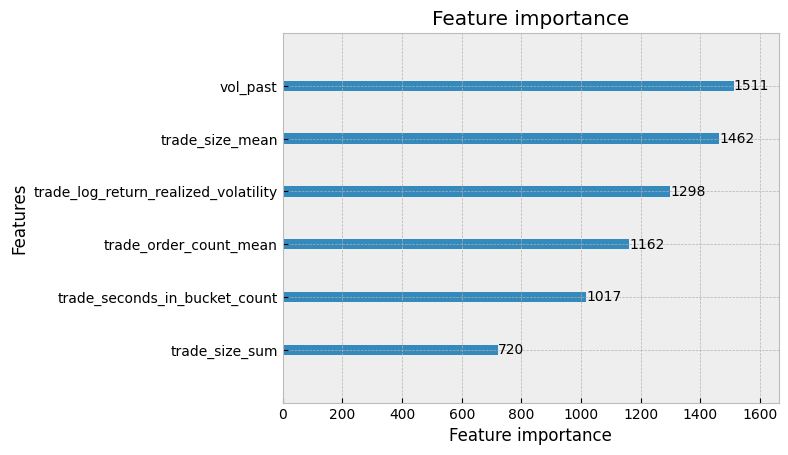

In [22]:
lgb.plot_importance(model, max_num_features=15)

In [23]:
test = pd.read_csv(DATA_DIR + 'test.csv')
test_stock_ids = test['stock_id'].unique()

test_book_stats = Parallel(n_jobs=-1, verbose=1)(
    delayed(get_stock_stat)(stock_id, DATA_DIR) 
    for stock_id in test_stock_ids
)
test_book_df = pd.concat(test_book_stats, ignore_index=True)

test_book_df = test_book_df.rename(columns={'log_return': 'vol_past'})

test_trade_stats = Parallel(n_jobs=-1, verbose=1)(
    delayed(get_trade_stat)(stock_id, DATA_DIR) 
    for stock_id in test_stock_ids
)
test_trade_df = pd.concat(test_trade_stats, ignore_index=True)

test_df = test.merge(test_book_df, on=['stock_id', 'time_id'], how='left')
test_df = test_df.merge(test_trade_df, on=['stock_id', 'time_id'], how='left')

test_df = test_df.fillna(0)

test_df['row_id'] = test_df['stock_id'].astype(str) + '-' + test_df['time_id'].astype(str)

X_test = test_df[feature_cols]
y_pred = model.predict(X_test)

submission = pd.DataFrame({
    'row_id': test_df['row_id'],
    'target': y_pred
})

#submission.to_csv('submission.csv', index=False)
#print(submission.head())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


In [24]:
def feature_engineering(df):
    df['wap1'] = calc_wap1(df)
    df['log_return'] = df.groupby('stock_id')['wap1'].transform(log_return)
    df['price_spread'] = (df['ask_price1'] - df['bid_price1']) / ((df['ask_price1'] + df['bid_price1']) / 2.0)
    df['total_volume'] = df['ask_size1'] + df['ask_size2'] + df['bid_size1'] + df['bid_size2']
    df['volume_imbalance'] = abs((df['ask_size1'] + df['ask_size2']) - (df['bid_size1'] + df['bid_size2']))

    feature_dict = {
        'log_return': [realized_volatility],
        'wap1': ['mean', 'std'],
        'price_spread': ['mean', 'max'],
        'volume_imbalance': ['mean'],
        'total_volume': ['mean']
    }

    features = df.groupby(['stock_id', 'time_id']).agg(feature_dict)

    features.columns = ['_'.join(col) for col in features.columns]
    features = features.reset_index();
    return features

In [25]:
from sklearn.model_selection import GroupKFold

def train_and_eval(train_df, features_col):
    params = {
        'objective': 'rmse',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.1,
        'num_leaves': 31,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42
    }
    
    kfold = GroupKFold(n_splits=5)
    oof_preds = np.zeros(len(train_df))
    models = []
    
    features_col = list(features_col)
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_df, groups=train_df['time_id'])):
        print(f'Training Fold {fold+1}...')
        
        X_train = train_df.loc[train_idx, features_col].values
        y_train = train_df.loc[train_idx, 'target'].values
        X_val = train_df.loc[val_idx, features_col].values
        y_val = train_df.loc[val_idx, 'target'].values
        
        train_weights = 1 / np.square(y_train)
        val_weights = 1 / np.square(y_val)
        
        dtrain = lgb.Dataset(X_train, label=y_train, weight=train_weights, feature_name=features_col)
        dval = lgb.Dataset(X_val, label=y_val, weight=val_weights, feature_name=features_col, reference=dtrain)
        
        model = lgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            valid_sets=[dtrain, dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)],
            feval=lgb_rmspe
        )
        
        models.append(model)
        oof_preds[val_idx] = model.predict(X_val)
        
    print(f"{rmspe(train_df['target'], oof_preds)}")
    return models, oof_preds

feature_cols = [col for col in df_joined.columns if col not in ['stock_id', 'time_id', 'target', 'row_id']]
model, predictions = train_and_eval(df_joined, feature_cols)

Training Fold 1...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000568186	training's RMSPE: 0.264443	valid_1's rmse: 0.000574463	valid_1's RMSPE: 0.259799
[100]	training's rmse: 0.000567884	training's RMSPE: 0.264303	valid_1's rmse: 0.000576279	valid_1's RMSPE: 0.26062
Early stopping, best iteration is:
[50]	training's rmse: 0.000568186	training's RMSPE: 0.264443	valid_1's rmse: 0.000574463	valid_1's RMSPE: 0.259799
Training Fold 2...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000564355	training's RMSPE: 0.260954	valid_1's rmse: 0.000598218	valid_1's RMSPE: 0.277861
[100]	training's rmse: 0.000564307	training's RMSPE: 0.260932	valid_1's rmse: 0.000598218	valid_1's RMSPE: 0.277861
Early stopping, best iteration is:
[80]	training's rmse: 0.000564323	training's RMSPE: 0.26094	valid_1's rmse: 0.000597992	valid_1's RMSPE: 0.277756
Training Fold 3...
Training until validation scores don't improve for 50 rounds


In [26]:
import pandas as pd
import numpy as np
import glob
from joblib import Parallel, delayed

def calc_realized_volatility(series):
    return np.sqrt(np.sum(series**2))

def get_trade_stat(file_path):
    try:
        df_trade = pd.read_parquet(file_path)
    except:
        return pd.DataFrame()

    stock_id = int(file_path.split('=')[1])
    
    df_trade['log_price'] = np.log(df_trade['price'])
    df_trade['log_return'] = df_trade.groupby('time_id')['log_price'].diff().fillna(0)
    
    aggregate_dict = {
        'log_return': [calc_realized_volatility],
        'seconds_in_bucket': ['count'],
        'size': ['sum'],
        'order_count': ['mean']
    }
    
    df_trade_agg = df_trade.groupby('time_id').agg(aggregate_dict)
    
    df_trade_agg.columns = ['trade_' + '_'.join(col) for col in df_trade_agg.columns]
    df_trade_agg = df_trade_agg.reset_index()
    df_trade_agg['stock_id'] = stock_id
    
    return df_trade_agg

DATA_DIR = '../input/competitions/optiver-realized-volatility-prediction/'
trade_files = glob.glob(f'{DATA_DIR}/trade_train.parquet/stock_id=*')

df_trade_features_list = Parallel(n_jobs=-1, verbose=1)(delayed(get_trade_stat)(f) for f in trade_files)
df_trade_features = pd.concat(df_trade_features_list, ignore_index=True)

df_joined_full = df_joined.merge(df_trade_features, on=['stock_id', 'time_id'], how='left')
df_joined_full = df_joined_full.fillna(0)

feature_cols_full = [c for c in df_joined_full.columns if c not in ['stock_id', 'time_id', 'target', 'row_id']]

model_v2, preds_v2 = train_and_eval(df_joined_full, feature_cols_full)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:   24.8s finished


Training Fold 1...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000528331	training's RMSPE: 0.245894	valid_1's rmse: 0.000556402	valid_1's RMSPE: 0.251631
[100]	training's rmse: 0.000522605	training's RMSPE: 0.243229	valid_1's rmse: 0.000553673	valid_1's RMSPE: 0.250397
[150]	training's rmse: 0.000519672	training's RMSPE: 0.241864	valid_1's rmse: 0.000552912	valid_1's RMSPE: 0.250052
[200]	training's rmse: 0.000517185	training's RMSPE: 0.240706	valid_1's rmse: 0.000552675	valid_1's RMSPE: 0.249945
[250]	training's rmse: 0.000515063	training's RMSPE: 0.239719	valid_1's rmse: 0.000552479	valid_1's RMSPE: 0.249857
[300]	training's rmse: 0.000513249	training's RMSPE: 0.238875	valid_1's rmse: 0.000552399	valid_1's RMSPE: 0.24982
Early stopping, best iteration is:
[270]	training's rmse: 0.000514281	training's RMSPE: 0.239355	valid_1's rmse: 0.000552321	valid_1's RMSPE: 0.249785
Training Fold 2...
Training until validation scores don't improve for 50 ro

In [27]:
def get_book_features(file_path):
    df = pd.read_parquet(file_path)
    stock_id = int(file_path.split('=')[1])
    
    # Podstawowe obliczenia
    df['wap1'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])
    df['log_return'] = df.groupby('time_id')['wap1'].transform(lambda x: np.log(x).diff().fillna(0))
    df['spread'] = (df['ask_price1'] - df['bid_price1']) / ((df['ask_price1'] + df['bid_price1']) / 2.0)
    
    create_feature_dict = {
        'log_return': [realized_volatility],
        'spread': ['mean'],
        'wap1': ['mean', 'std']
    }
    
    # 1. Agregacja bazowa (0-600s)
    features = df.groupby('time_id').agg(create_feature_dict)
    features.columns = ['_'.join(col).strip('_') for col in features.columns]
    features = features.reset_index()
    features['stock_id'] = stock_id
    
    # 2. Okna czasowe
    for seconds in [300, 150]:
        df_subset = df[df['seconds_in_bucket'] >= (600 - seconds)]
        df_temp = df_subset.groupby('time_id').agg(create_feature_dict)
        
        # Zmieniamy nazwy kolumn TYLKO dla cech, dodając suffix okna
        df_temp.columns = ['_'.join(col).strip('_') + f'_{seconds}' for col in df_temp.columns]
        df_temp = df_temp.reset_index()
        
        # Łączymy po time_id - teraz obie strony mają tę kolumnę
        features = features.merge(df_temp, on='time_id', how='left')
        
    return features

def get_trade_features(file_path):
    try:
        df = pd.read_parquet(file_path)
    except: return pd.DataFrame()
    
    stock_id = int(file_path.split('=')[1])
    df['log_return'] = df.groupby('time_id')['price'].transform(lambda x: np.log(x).diff().fillna(0))
    
    create_feature_dict = {
        'log_return': [realized_volatility],
        'seconds_in_bucket': ['count'],
        'size': ['sum']
    }
    
    # 1. Agregacja bazowa
    features = df.groupby('time_id').agg(create_feature_dict)
    features.columns = ['_'.join(col).strip('_') for col in features.columns]
    features = features.reset_index()
    features['stock_id'] = stock_id
    
    # 2. Okna czasowe
    for seconds in [300, 150]:
        df_subset = df[df['seconds_in_bucket'] >= (600 - seconds)]
        df_temp = df_subset.groupby('time_id').agg(create_feature_dict)
        df_temp.columns = ['_'.join(col).strip('_') + f'_{seconds}' for col in df_temp.columns]
        df_temp = df_temp.reset_index()
        
        features = features.merge(df_temp, on='time_id', how='left')
    
    return features

In [28]:
book_files = glob.glob(f'{DATA_DIR}/book_train.parquet/stock_id=*')
trade_files = glob.glob(f'{DATA_DIR}/trade_train.parquet/stock_id=*')

df_book_final = pd.concat(Parallel(n_jobs=-1, verbose=1)(delayed(get_book_features)(f) for f in book_files), ignore_index=True)
df_trade_final = pd.concat(Parallel(n_jobs=-1, verbose=1)(delayed(get_trade_features)(f) for f in trade_files), ignore_index=True)

df_train_full = pd.read_csv(f'{DATA_DIR}/train.csv')
df_train_full['row_id'] = df_train_full['stock_id'].astype(str) + '-' + df_train_full['time_id'].astype(str)

df_joined = df_train_full.merge(df_book_final, on=['stock_id', 'time_id'], how='left')
df_joined = df_joined.merge(df_trade_final, on=['stock_id', 'time_id'], how='left')
df_joined = df_joined.fillna(0)

feature_cols = [c for c in df_joined.columns if c not in ['stock_id', 'time_id', 'target', 'row_id']]

model_v3, preds_v3 = train_and_eval(df_joined, feature_cols)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   56.8s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:  2.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   50.4s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:  2.2min finished


Training Fold 1...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000507292	training's RMSPE: 0.236102	valid_1's rmse: 0.000535969	valid_1's RMSPE: 0.24239
[100]	training's rmse: 0.000498244	training's RMSPE: 0.231891	valid_1's rmse: 0.000530513	valid_1's RMSPE: 0.239923
[150]	training's rmse: 0.000493102	training's RMSPE: 0.229498	valid_1's rmse: 0.000528155	valid_1's RMSPE: 0.238856
[200]	training's rmse: 0.0004894	training's RMSPE: 0.227775	valid_1's rmse: 0.000527248	valid_1's RMSPE: 0.238446
[250]	training's rmse: 0.000486325	training's RMSPE: 0.226344	valid_1's rmse: 0.000526962	valid_1's RMSPE: 0.238317
Early stopping, best iteration is:
[240]	training's rmse: 0.000486849	training's RMSPE: 0.226588	valid_1's rmse: 0.000526704	valid_1's RMSPE: 0.2382
Training Fold 2...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000513117	training's RMSPE: 0.237262	valid_1's rmse: 0.000533826	valid_1's RMSPE: 0.247952


In [29]:
market_stats = df_joined.groupby('time_id')['log_return_realized_volatility_x'].agg(['mean', 'std', 'max']).reset_index()
market_stats.columns = ['time_id', 'market_vol_mean', 'market_vol_std', 'market_vol_max']
df_joined_v4 = df_joined.merge(market_stats, on='time_id', how='left')
feature_cols_v4 = [c for c in df_joined_v4.columns if c not in ['stock_id', 'time_id', 'target', 'row_id']]
model_v4, preds_v4 = train_and_eval(df_joined_v4, feature_cols_v4)

Training Fold 1...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000496032	training's RMSPE: 0.230861	valid_1's rmse: 0.000530583	valid_1's RMSPE: 0.239954
[100]	training's rmse: 0.000479157	training's RMSPE: 0.223008	valid_1's rmse: 0.000524561	valid_1's RMSPE: 0.237231
[150]	training's rmse: 0.000468442	training's RMSPE: 0.218021	valid_1's rmse: 0.000524317	valid_1's RMSPE: 0.237121
Early stopping, best iteration is:
[125]	training's rmse: 0.00047401	training's RMSPE: 0.220612	valid_1's rmse: 0.00052351	valid_1's RMSPE: 0.236755
Training Fold 2...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000502334	training's RMSPE: 0.232276	valid_1's rmse: 0.000525842	valid_1's RMSPE: 0.244244
[100]	training's rmse: 0.000484772	training's RMSPE: 0.224156	valid_1's rmse: 0.000524175	valid_1's RMSPE: 0.24347
Early stopping, best iteration is:
[70]	training's rmse: 0.000494262	training's RMSPE: 0.228544	valid_1's rmse: 0.

In [30]:
stock_stats = df_joined_v4.groupby('stock_id')['log_return_realized_volatility_x'].agg(['mean', 'std', 'median']).reset_index()
stock_stats.columns = ['stock_id', 'stock_vol_mean', 'stock_vol_std', 'stock_vol_median']
df_joined_v5 = df_joined_v4.merge(stock_stats, on='stock_id', how='left')
df_joined_v5['rel_vol'] = df_joined_v5['log_return_realized_volatility_x'] / df_joined_v5['stock_vol_mean']
feature_cols_v5 = [c for c in df_joined_v5.columns if c not in ['stock_id', 'time_id', 'target', 'row_id']]

model_v5, preds_v5 = train_and_eval(df_joined_v5, feature_cols_v5)

Training Fold 1...
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 0.000485649	training's RMSPE: 0.226029	valid_1's rmse: 0.000519415	valid_1's RMSPE: 0.234903
[100]	training's rmse: 0.000468818	training's RMSPE: 0.218196	valid_1's rmse: 0.000515717	valid_1's RMSPE: 0.233231
[150]	training's rmse: 0.000457422	training's RMSPE: 0.212892	valid_1's rmse: 0.000514823	valid_1's RMSPE: 0.232827
[200]	training's rmse: 0.000450162	training's RMSPE: 0.209513	valid_1's rmse: 0.000513771	valid_1's RMSPE: 0.232351
[250]	training's rmse: 0.000443478	training's RMSPE: 0.206402	valid_1's rmse: 0.000513504	valid_1's RMSPE: 0.23223
[300]	training's rmse: 0.000438204	training's RMSPE: 0.203948	valid_1's rmse: 0.000513601	valid_1's RMSPE: 0.232274
[350]	training's rmse: 0.000433382	training's RMSPE: 0.201703	valid_1's rmse: 0.000513129	valid_1's RMSPE: 0.232061
Early stopping, best iteration is:
[348]	training's rmse: 0.000433632	training's RMSPE: 0.201819	valid_1's rms

In [31]:
checkpoint_oof = pd.DataFrame({
    'row_id': df_joined_v5['row_id'],
    'prediction': preds_v5,
    'target': df_joined_v5['target']
})
checkpoint_oof.to_csv('oof_predictions_0.233.csv', index=False)

In [32]:
import os

test = pd.read_csv('../input/competitions/optiver-realized-volatility-prediction/test.csv')
test['row_id'] = test['stock_id'].astype(str) + '-' + test['time_id'].astype(str)
test_stock_ids = test['stock_id'].unique()

TEST_DATA_DIR = '../input/competitions/optiver-realized-volatility-prediction/'

def get_test_book(stock_id):
    path = f'{TEST_DATA_DIR}book_test.parquet/stock_id={stock_id}'
    return get_book_features(path)

def get_test_trade(stock_id):
    path = f'{TEST_DATA_DIR}trade_test.parquet/stock_id={stock_id}'
    return get_trade_features(path)

test_book_list = Parallel(n_jobs=-1)(delayed(get_test_book)(s) for s in test_stock_ids)
test_trade_list = Parallel(n_jobs=-1)(delayed(get_test_trade)(s) for s in test_stock_ids)

df_test_book = pd.concat(test_book_list, ignore_index=True)
df_test_trade = pd.concat(test_trade_list, ignore_index=True)

df_test_joined = test.merge(df_test_book, on=['stock_id', 'time_id'], how='left')
df_test_joined = df_test_joined.merge(df_test_trade, on=['stock_id', 'time_id'], how='left')
df_test_joined = df_test_joined.fillna(0)

df_test_joined = df_test_joined.merge(market_stats, on='time_id', how='left')
df_test_joined = df_test_joined.merge(stock_stats, on='stock_id', how='left')

df_test_joined['rel_vol'] = df_test_joined['log_return_realized_volatility_x'] / df_test_joined['stock_vol_mean']

X_test = df_test_joined[feature_cols_v5].values
final_test_preds = np.zeros(len(X_test))

for m in model_v5:
    final_test_preds += m.predict(X_test) / len(model_v5)

submission = pd.DataFrame({
    'row_id': df_test_joined['row_id'],
    'target': final_test_preds
})

submission.to_csv('submission.csv', index=False)